In [ ]:
import os
import torch
import torchaudio
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import librosa

from scipy.signal import welch
from tqdm.auto import tqdm

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Run Model on: {DEVICE}")

Run Model on: cuda


# Prepare Data for EDA

In [3]:
LABEL_CSV = 'dataset/state_labels.csv'
RAW_AUDIO_DIR = 'dataset'
WINDOW_SEC = 7.0

df_labels = pd.read_csv(LABEL_CSV)
eda_records = []

print("Finding all audio files in folder...")
audio_files_map = {}
for root, dirs, files in os.walk(RAW_AUDIO_DIR):
    for file in files:
        if file.endswith('.wav') or file.endswith('.mp3'):
            base_name = os.path.splitext(file)[0]
            audio_files_map[base_name] = os.path.join(root, file)

print(f"Found {len(audio_files_map)} files ready for sliding-window EDA.")


for _, row in tqdm(df_labels.iterrows(), total=len(df_labels)):
    sample_name = str(row['sample_name']).strip()
    label = str(row['label']).strip().lower()

    if label not in ['active', 'missing queen']: 
        continue
    if sample_name not in audio_files_map:
        continue 
        
    file_path = audio_files_map[sample_name]
    hive_id = sample_name.split('_')[0]
    
    try:
        y_full, sr = librosa.load(file_path, sr=None)
        total_samples = len(y_full)
        chunk_samples = int(sr * WINDOW_SEC)

        for start_sample in range(0, total_samples, chunk_samples):
            end_sample = start_sample + chunk_samples
            if end_sample > total_samples: 
                break
                

            y_chunk = y_full[start_sample:end_sample]
            
            duration = len(y_chunk) / sr
            

            rms = librosa.feature.rms(y=y_chunk)
            mean_rms = np.mean(rms)

            zcr = librosa.feature.zero_crossing_rate(y=y_chunk)
            mean_zcr = np.mean(zcr)
            
            # Signal-to-Noise Ratio
            rms_frames = rms[0]
            if len(rms_frames) > 0:
                p_signal = np.percentile(rms_frames, 90) ** 2
                p_noise = np.percentile(rms_frames, 10) ** 2
                snr = 10 * np.log10(p_signal / p_noise) if p_noise > 0 else 0
            else:
                snr = 0
                
            freqs, psd = welch(y_chunk, sr, nperseg=min(len(y_chunk), 2048))
            dominant_freq = freqs[np.argmax(psd)] if len(psd) > 0 else 0

            eda_records.append({
                'label': label,
                'hive': hive_id,
                'duration': duration,
                'rms': mean_rms,
                'zcr': mean_zcr,
                'snr': snr,
                'dominant_freq': dominant_freq,
                'file_source': sample_name
            })

    except Exception as e:
        pass

Finding all audio files in folder...
Found 288 files ready for sliding-window EDA.


  0%|          | 0/573 [00:00<?, ?it/s]

# Exploratory Data Analysis (EDA)

Found 288 files ready for sliding-window


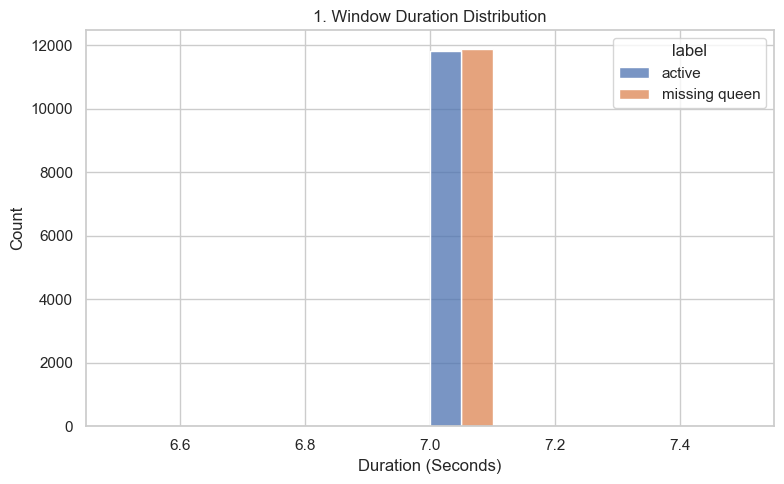

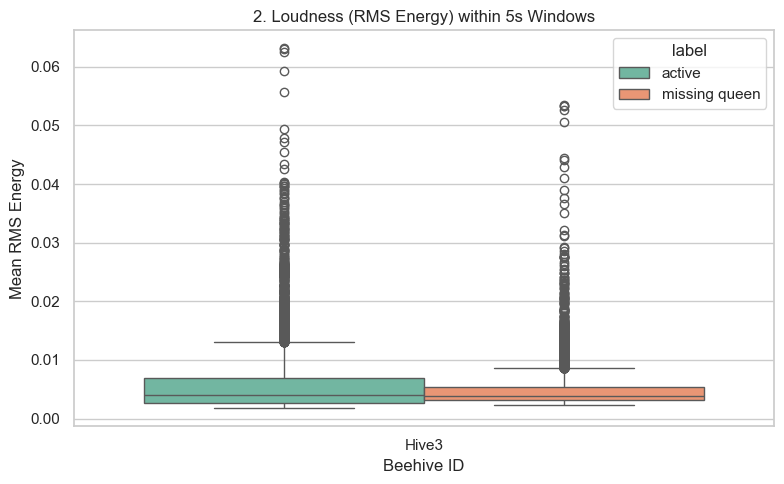

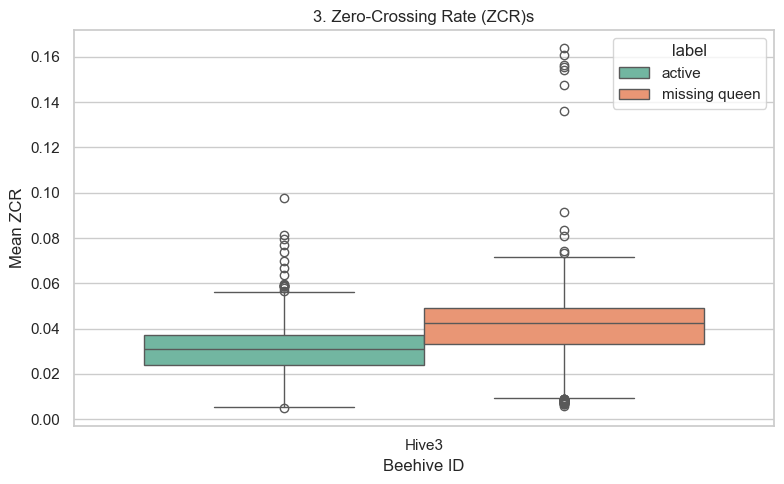

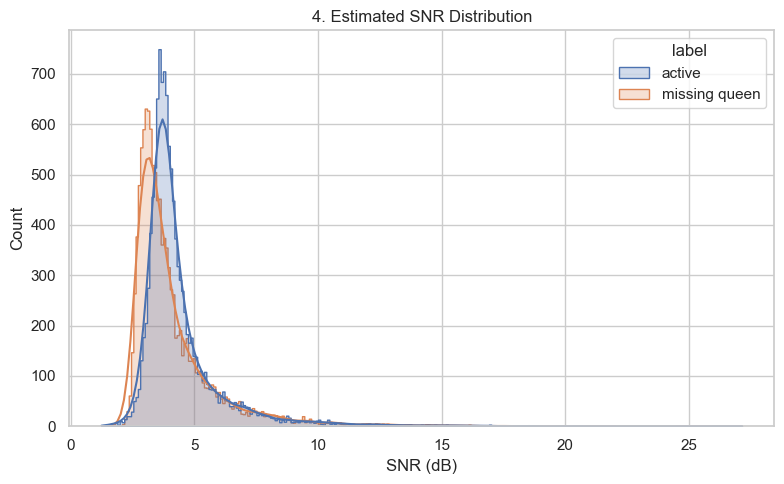

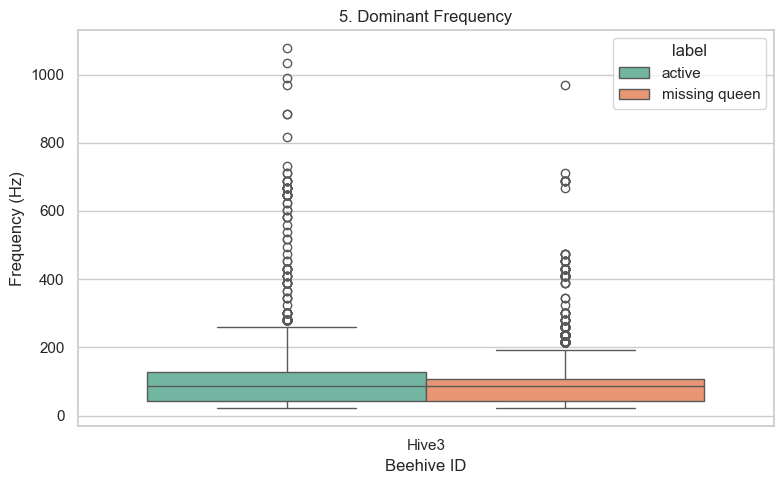

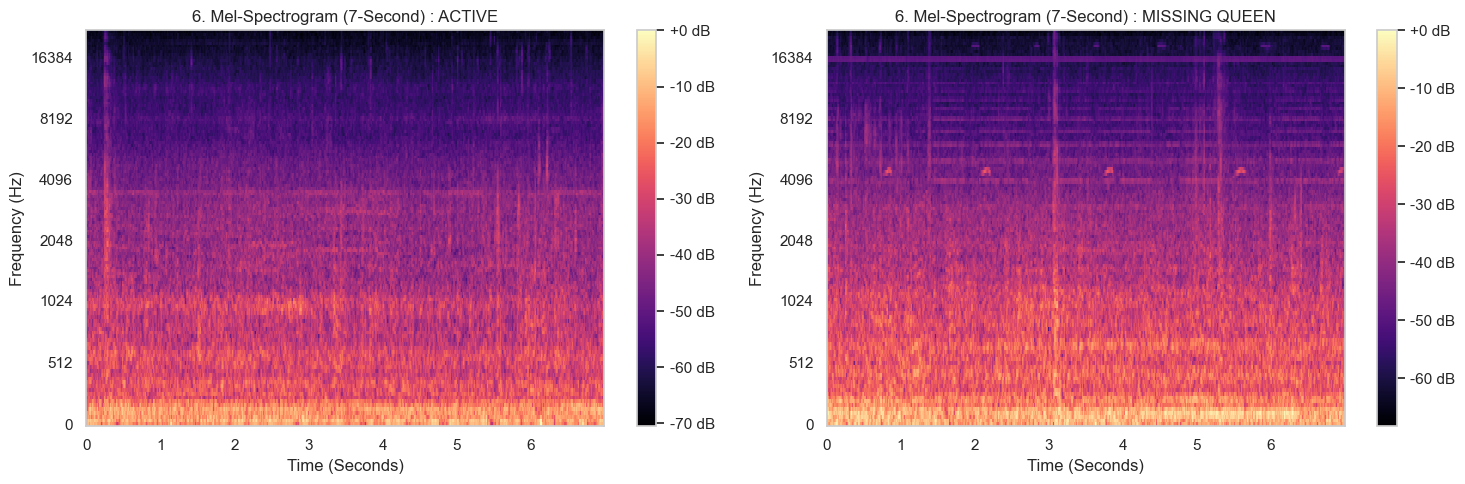

In [7]:
window_eda_df = pd.DataFrame(eda_records)
if window_eda_df.empty:
    print("No data found")
else:
    print(f"Found {len(audio_files_map)} files ready for sliding-window")
    sns.set_theme(style="whitegrid")

    # Audio Length Distribution
    plt.figure(figsize=(8, 5))
    sns.histplot(data=window_eda_df, x='duration', hue='label', multiple='dodge', bins=10)
    plt.title('1. Window Duration Distribution')
    plt.xlabel('Duration (Seconds)')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # Amplitude / RMS Energy
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=window_eda_df, x='hive', y='rms', hue='label', palette='Set2')
    plt.title('2. Loudness (RMS Energy) within 5s Windows')
    plt.xlabel('Beehive ID')
    plt.ylabel('Mean RMS Energy')
    plt.tight_layout()
    plt.show()

    # Zero-Crossing Rate
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=window_eda_df, x='hive', y='zcr', hue='label', palette='Set2')
    plt.title('3. Zero-Crossing Rate (ZCR)s')
    plt.xlabel('Beehive ID')
    plt.ylabel('Mean ZCR')
    plt.tight_layout()
    plt.show()

    # Estimated SNR
    plt.figure(figsize=(8, 5))
    sns.histplot(data=window_eda_df, x='snr', hue='label', kde=True, element='step')
    plt.title('4. Estimated SNR Distribution')
    plt.xlabel('SNR (dB)')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # Dominant Frequency
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=window_eda_df, x='hive', y='dominant_freq', hue='label', palette='Set2')
    plt.title('5. Dominant Frequency')
    plt.xlabel('Beehive ID')
    plt.ylabel('Frequency (Hz)')
    plt.tight_layout()
    plt.show()

    # Mel-Spectrogram
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    unique_labels = ['active', 'missing queen']
    spectrogram_plotted = False

    for i, cls in enumerate(unique_labels):
        sample_rows = window_eda_df[window_eda_df['label'] == cls]
        if len(sample_rows) > 0:

            source_file = sample_rows['file_source'].iloc[0]
            file_path = audio_files_map[source_file]
            
            if os.path.exists(file_path):
                y_chunk, sr = librosa.load(file_path, sr=None, duration=WINDOW_SEC)
                S = librosa.feature.melspectrogram(y=y_chunk, sr=sr, n_mels=128)
                S_dB = librosa.power_to_db(S, ref=np.max)
                
                img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=axes[i], cmap='magma')
                axes[i].set_title(f'6. Mel-Spectrogram (7-Second) : {cls.upper()}')
                axes[i].set_xlabel('Time (Seconds)')
                axes[i].set_ylabel('Frequency (Hz)')
                fig.colorbar(img, ax=axes[i], format='%+2.0f dB')
                spectrogram_plotted = True

    if spectrogram_plotted:
        plt.tight_layout()
        plt.show()
    else:
        plt.close()